In [60]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
import torch
from utils.model_base_utils import (
    get_device,
    load_model_and_tokenizer
)

In [62]:
device = get_device()
device = torch.device("cpu")
 
model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


In [63]:
from utils.model_eval_utils import (
    render_prompt,
    extract_final_candidate,
    grade_answer,
    avg_logprob_answer
    
)
from utils.text_utils import (
    generate_text_stream_concat_flex,
    generate_text_top_p_stream_cache,
    self_consistency_vote,
    sample_response
)

ImportError: cannot import name 'avg_logprob_answer' from 'utils.model_eval_utils' (/Users/nikhilgupta/gitPersonal/reasoning/utils/model_eval_utils.py)

In [ ]:
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)
 
torch.manual_seed(0)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9
)
print(response)

In [ ]:
import json
import requests
from pathlib import Path
 
def load_math_train(local_path="math_train.json", save_copy=True):
    local_path = Path(local_path)
 
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "math_full_minus_math500/refs/heads/main/"
        "math_full_minus_math500.json"
    )
    backup_url = (
        "https://f001.backblazeb2.com/file/reasoning-from-scratch/"
        "MATH/math_full_minus_math500.json"
    )
 
    if local_path.exists():
        with local_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
    else:
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
        except requests.RequestException:
            print("Using backup URL.")
            r = requests.get(backup_url, timeout=30)
            r.raise_for_status()
 
        data = r.json()
 
        if save_copy:
            with local_path.open("w", encoding="utf-8") as f:
                json.dump(data, f, indent=2)
 
    return data
 

In [ ]:
math_train = load_math_train()
len(math_train)

In [ ]:
from pprint import pprint
pprint(math_train[4])

In [72]:
torch.manual_seed(0)
 
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)
 
token_ids, prompt_len, answer_text = sample_response(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            device=device,
            max_new_tokens=512,
            temperature=0.9,
            top_p=0.9,
        )

In [ ]:
token_ids

In [25]:
prompt_len

57

In [26]:
answer_text

" \\boxed{58}\nTo solve the problem, we need to follow these steps:\n\n1. Define the equation based on the given information.\n2. Solve the equation for \\(x\\).\n\nLet's break it down:\n\nThe problem states that half the value of \\(3x - 9\\) is \\(x + 37\\). Therefore, we can write the equation as:\n\\[\n\\frac{1}{2}(3x - 9) = x + 37\n\\]\n\nNow, let's solve this equation step by step.\n\n1. Distribute the \\(\\frac{1}{2}\\) on the left side of the equation:\n\\[\n3x - 9 = 2(x + 37)\n\\]\n\n2. Expand the right side of the equation:\n\\[\n3x - 9 = 2x + 74\n\\]\n\n3. Subtract \\(2x\\) from both sides to isolate the \\(x\\) terms on one side:\n\\[\n3x - 2x - 9 = 74\n\\]\n\\[\nx - 9 = 74\n\\]\n\n4. Add 9 to both sides to solve for \\(x\\):\n\\[\nx = 74 + 9\n\\]\n\\[\nx = 83\n\\]\n\nLet's verify the solution by substituting \\(x = 83\\) back into the original equation to ensure it holds true. We'll use Python code to do this calculation and confirm the result.\n```python\n# Define the val

In [27]:
rollouts = [
    r"\boxed{83}",
    r"The correct answer is \boxed{83}",
    r"The final answer is 83",
    r"We get \boxed{38}",
]

## Implementing the reward function

In [29]:
def reward_rlvr(answer_text, ground_truth):
    extracted = extract_final_candidate(
        answer_text, fallback=None # fallback=None requires \boxed{} format to return an extracted answer
    )
    if not extracted:
        return 0.0
    correct = grade_answer(extracted, ground_truth)
    return float(correct)

In [37]:
rollout_rewards = []
 
for answer in rollouts:
    reward = reward_rlvr(answer_text=answer, ground_truth="83")
    print(f"Answer: {answer!r}") # !r --> __repr__() [exact syntax needed to recreate the object (like adding quotes around strings)]
    print(f"Reward: {reward}\n")
    rollout_rewards.append(reward)


Answer: '\\boxed{83}'
Reward: 1.0

Answer: 'The correct answer is \\boxed{83}'
Reward: 1.0

Answer: 'The final answer is 83'
Reward: 0.0

Answer: 'We get \\boxed{38}'
Reward: 0.0



In [34]:
def partial_reward_rlvr(answer_text, ground_truth):
    
    # 1) Try to extract a boxed answer
    boxed = extract_final_candidate(
        answer_text, fallback=None
    )
    if boxed:
        correct = grade_answer(boxed, ground_truth)
        return 1.0 if correct else 0.0

    # 2) If no boxed answer is found, look for number
    unboxed = extract_final_candidate(
        answer_text, fallback="number_then_full"
    )
    if unboxed:
        correct = grade_answer(unboxed, ground_truth)
        return 0.5 if correct else 0.0

    return 0.0

In [69]:
rollout_rewards = []
 
for answer in rollouts:
    reward = partial_reward_rlvr(answer_text=answer, ground_truth="83")
    print(f"Answer: {answer!r}") # !r --> __repr__() [exact syntax needed to recreate the object (like adding quotes around strings)]
    print(f"Reward: {reward}\n")
    rollout_rewards.append(reward)

Answer: '\\boxed{83}'
Reward: 1.0

Answer: 'The correct answer is \\boxed{83}'
Reward: 1.0

Answer: 'The final answer is 83'
Reward: 0.5

Answer: 'We get \\boxed{38}'
Reward: 0.0



## Calculating Advantage

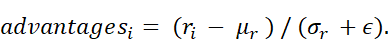

* 𝑟𝑖 denotes the reward of the i-th rollout,
* 𝜇𝑟 is the mean reward across the group of rollouts,
* σ𝑟 is the corresponding standard deviation, and
* ϵ is a small constant added for numerical stability to avoid zero-division errors.

In [70]:
rewards = torch.tensor(rollout_rewards, device=device)
advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)
print(f"rewards: {rewards}")
print(f"dvantages: {advantages}")

rewards: tensor([1.0000, 1.0000, 0.5000, 0.0000])
dvantages: tensor([ 0.7832,  0.7832, -0.2611, -1.3053])


### Zero Advantage Cases

In [41]:
rollout_rewards = [0., 0., 0., 0.]
rewards = torch.tensor(rollout_rewards)
advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

print(advantages)

tensor([0., 0., 0., 0.])


In [42]:
rollout_rewards = [1., 1., 1., 1.]
rewards = torch.tensor(rollout_rewards)
advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

print(advantages)

tensor([0., 0., 0., 0.])


#### Observation

* Now, if all advantages are 0, the loss will be zero as well, because the loss multiplies the advantages by the log probabilities, and multiplying by zero eliminates the contribution
    * pg_loss = -(advantages.detach() * logps).mean()
* As a result, the policy gradient is zero and the model parameters are not updated for that prompt
* This behavior is intentional; if all rollouts are equally bad or equally good, there is no relative signal to tell the model which behavior to reinforce or suppress.
* Intuitively, if the model answers all the questions correctly, there is no need to update it.
* Vice versa, if the model answers all questions incorrectly, we don't want to update the model to reinforce this behavior

In [75]:
@torch.inference_mode()
def avg_logprob_answer(model, tokenizer, prompt, answer, device="cpu"):
 
    prompt_ids = tokenizer.encode(prompt)
    answer_ids = tokenizer.encode(answer)
    full_ids = torch.tensor(prompt_ids + answer_ids, device=device)
 
    logits = model(full_ids.unsqueeze(0)).squeeze(0)
    logprobs = torch.log_softmax(logits, dim=-1)
 
    start = len(prompt_ids) - 1
    end = full_ids.shape[0] - 1
 
    t_idx = torch.arange(start, end, device=device)
    next_tokens = full_ids[start + 1 : end + 1]
    next_token_logps = logprobs[t_idx, next_tokens]
 
    return torch.mean(next_token_logps).item()
    # return torch.sum(next_token_logps).item()

In [78]:
avg_logprob_val = avg_logprob_answer(
                   model, tokenizer, 
                   prompt=prompt,
                   answer=answer_text,
                   device=device) 
print(avg_logprob_val)

-89.0


In [79]:
sequence_logprob_val = avg_logprob_val * (
    len(tokenizer.encode(answer_text))
)
print(sequence_logprob_val)

-43610.0


In [80]:
def sequence_logprob_draft(model, token_ids, prompt_len):
    logits = model(token_ids.unsqueeze(0)).squeeze(0).float()
    logprobs = torch.log_softmax(logits, dim=-1)
 
    start = prompt_len - 1
    end = token_ids.shape[0] - 1
 
    t_idx = torch.arange(start, end, device=token_ids.device)
    next_tokens = token_ids[start + 1 : end + 1]
    next_token_logps = logprobs[t_idx, next_tokens]
 
    return torch.sum(next_token_logps)
 
print(sequence_logprob_draft(model, token_ids, prompt_len))
 

tensor(-89.1638, grad_fn=<SumBackward0>)


In [81]:
def sequence_logprob(model, token_ids, prompt_len):
    logits = model(token_ids.unsqueeze(0)).squeeze(0).float()
    logprobs = torch.log_softmax(logits, dim=-1)

    # directly select the logprob corresponding to the generated tokens
    selected = logprobs[:-1].gather(
        1, token_ids[1:].unsqueeze(-1)
    ).squeeze(-1)
    return torch.sum(selected[prompt_len - 1:])
 
print(sequence_logprob(model, token_ids, prompt_len))

tensor(-89.1638, grad_fn=<SumBackward0>)


In [82]:
rollouts = [
    r"\boxed{83}",
    r"The correct answer is \boxed{83}",
    r"The final answer is 83",
    r"We get \boxed{38}",
]
 
rollout_logps = []
 
for text in rollouts:
    token_ids = tokenizer.encode(prompt + " " + text)
    logprob = sequence_logprob(
        model=model,
        token_ids=torch.tensor(token_ids, device=device),
        prompt_len=prompt_len,
    )
 
    print(f"Answer:  {text}")
    print(f"Logprob: {logprob.item():.4f}\n")
 
    rollout_logps.append(logprob)
 

Answer:  \boxed{83}
Logprob: -7.9803

Answer:  The correct answer is \boxed{83}
Logprob: -19.9670

Answer:  The final answer is 83
Logprob: -16.7747

Answer:  We get \boxed{38}
Logprob: -23.0317

